### plot 2d plot and save npz, get min

Saved main NPZ to: C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data\SnailSpec_twotone_sideq_versus_flu_20260704_1906_to_20260705_0600_I.npz


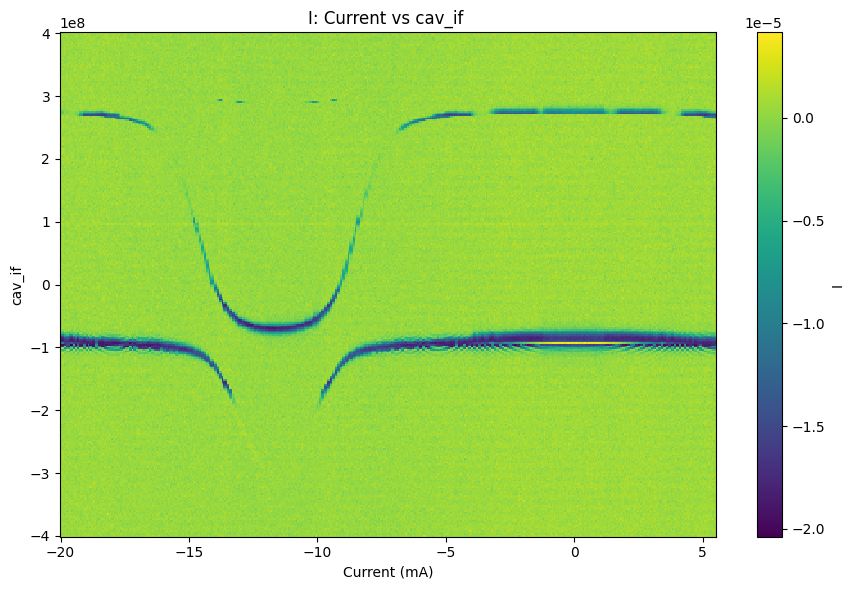

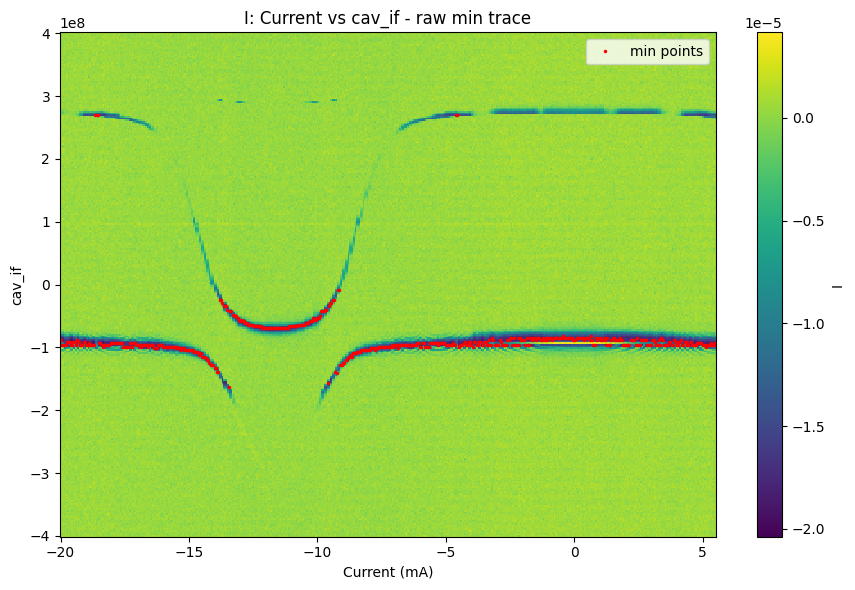

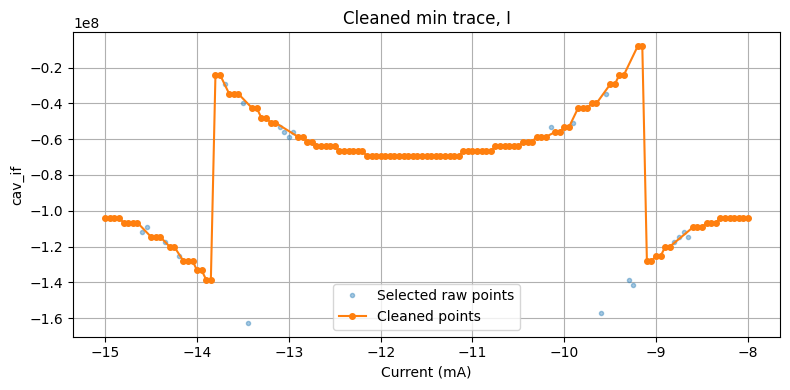

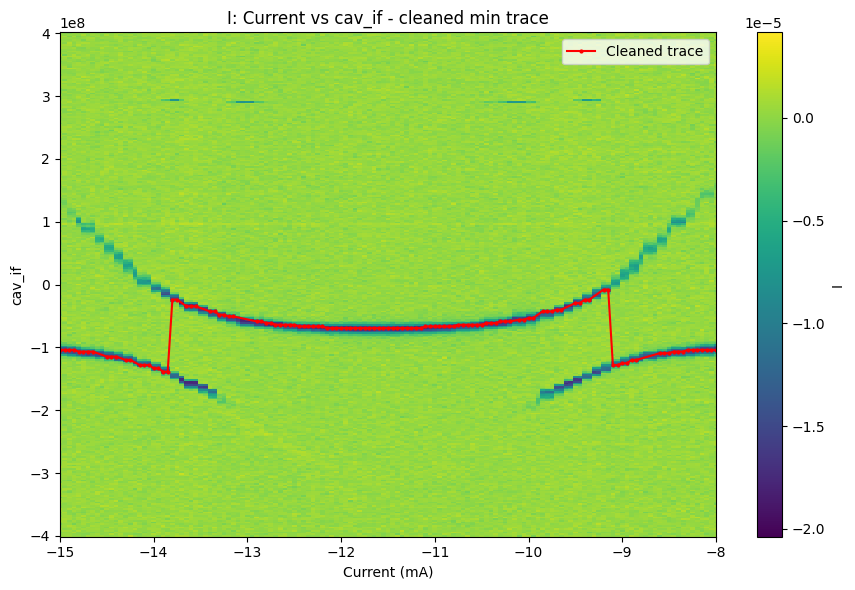


current = [-15, -14.95, -14.9, -14.85, -14.8, -14.75, -14.7, -14.65, -14.5, -14.45, -14.4, -14.3, -14.25, -14.15, -14.1, -14.05, -14, -13.95, -13.9, -13.85, -13.8, -13.75, -13.65, -13.6, -13.55, -13.4, -13.35, -13.3, -13.25, -13.2, -13.15, -12.9, -12.85, -12.8, -12.75, -12.7, -12.65, -12.6, -12.55, -12.5, -12.45, -12.4, -12.35, -12.3, -12.25, -12.2, -12.15, -12.1, -12.05, -12, -11.95, -11.9, -11.85, -11.8, -11.75, -11.7, -11.65, -11.6, -11.55, -11.5, -11.45, -11.4, -11.35, -11.3, -11.25, -11.2, -11.15, -11.1, -11.05, -11, -10.95, -10.9, -10.85, -10.8, -10.75, -10.7, -10.65, -10.6, -10.55, -10.5, -10.45, -10.4, -10.35, -10.3, -10.25, -10.2, -10.1, -10.05, -10, -9.95, -9.85, -9.8, -9.75, -9.7, -9.65, -9.5, -9.45, -9.4, -9.35, -9.2, -9.15, -9.1, -9.05, -9, -8.95, -8.9, -8.85, -8.6, -8.55, -8.5, -8.45, -8.4, -8.35, -8.3, -8.25, -8.2, -8.15, -8.1, -8.05, -8]

cav_if = [-104000074, -104000074, -104000074, -104000074, -106666740, -106666740, -106666740, -106666740, -114666738, -114666738, -1

In [1]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# USER SETTINGS
# ==========================================================
build_npz_from_hdf5 = True
load_npz_for_analysis = True

batches = [
    {
        "date": "2026-07-04",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-04",
        "time": ((19, 6), (23, 59)),
        "current": np.linspace(-20e-3, 20e-3, 801)[0:237],
    },
    {
        "date": "2026-07-05",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-05",
        "time": ((0, 0), (6, 0)),
        "current": np.linspace(-20e-3, 20e-3, 801)[237:237+274],
    },
]

file_key = "SnailSpec_twotone_sideq_versus_flu"
plot_data = "I"          # "I", "Q", or "MAG"
y_key = None             # None -> auto-choose sweep axis
subtract_mean = True
x_label, y_label = "Current", "cav_if"
show_individual_plots = False
plot_current_in_mA = True
output_folder = r"C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data"
os.makedirs(output_folder, exist_ok=True)

# Generate names dynamically
st_d, end_d = batches[0]["date"].replace("-", ""), batches[-1]["date"].replace("-", "")
st_h, st_m = batches[0]["time"][0]
end_h, end_m = batches[-1]["time"][1]
save_npz_name = f"{file_key}_{st_d}_{st_h:02d}{st_m:02d}_to_{end_d}_{end_h:02d}{end_m:02d}_{plot_data}.npz"
npz_path = os.path.join(output_folder, save_npz_name)

# Trace & Outlier Settings
find_mode = "min"        # "min" or "max"
current_min_mA, current_max_mA = -15, -8
remove_outliers = True
jump_threshold = 0.005   # 5 MHz if in GHz
save_min_trace = True

# ==========================================================
# HELPER FUNCTIONS
# ==========================================================

def extract_time(filename):
    try:
        parts = os.path.basename(filename).split("-")
        return (int(parts[0]), int(parts[1]))
    except Exception:
        return (-1, -1)

def get_filtered_files(folder, start_time, end_time, file_key):
    if not os.path.exists(folder):
        print(f"Folder not found: {folder}")
        return []
    files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".hdf5") and file_key in f]
    return sorted([f for f in files if start_time <= extract_time(f) <= end_time])

def load_one_hdf5(filename, y_key=None, subtract_mean=True):
    with h5py.File(filename, "r") as f:
        key = y_key or next(k for k in f.keys() if k not in {"I", "Q", "Magnitude"})
        y_vals = np.array(f[key][()])
        
        # Flatten array averages instantly
        I_val = np.mean(f["I"][()], axis=0) if f["I"].ndim > 1 else np.array(f["I"][()])
        Q_val = np.mean(f["Q"][()], axis=0) if f["Q"].ndim > 1 else np.array(f["Q"][()])
        mag_val = np.mean(f["Magnitude"][()], axis=0) if "Magnitude" in f.keys() else np.sqrt(I_val**2 + Q_val**2)

        if subtract_mean:
            I_val -= np.mean(I_val)
            Q_val -= np.mean(Q_val)
            mag_val -= np.mean(mag_val)
            
    return key, y_vals, I_val, Q_val, mag_val

def base_mesh_plot(x, y, z, title_suffix=""):
    """Consolidated 2D Mesh plotting template to remove duplicate code block."""
    plt.figure(figsize=(9, 6))
    x_plot = x * 1e3 if plot_current_in_mA else x
    plt.pcolormesh(x_plot, y, z.T, shading="auto", cmap="viridis")
    plt.xlabel(f"{x_label} ({'mA' if plot_current_in_mA else 'A'})")
    plt.ylabel(y_label)
    plt.title(f"{plot_data}: {x_label} vs {y_label} {title_suffix}")
    plt.colorbar(label=plot_data)
    plt.tight_layout()

# ==========================================================
# PROCESSING & ANALYSIS
# ==========================================================

if build_npz_from_hdf5:
    grouped_files, x_values, file_dates, file_times = [], [], [], []
    
    for b in batches:
        files = get_filtered_files(b["folder"], b["time"][0], b["time"][1], file_key)
        n = min(len(files), len(b["current"]))
        
        grouped_files.extend(files[:n])
        x_values.extend(b["current"][:n])
        file_dates.extend([b["date"]] * n)
        file_times.extend([extract_time(f) for f in files[:n]])

    if not grouped_files:
        raise ValueError("No matching HDF5 files found.")

    I_2d, Q_2d, MAG_2d, sweep_axis = [], [], [], []
    for i, fname in enumerate(grouped_files):
        key, y_vals, I_v, Q_v, M_v = load_one_hdf5(fname, y_key, subtract_mean)
        sweep_axis.append(y_vals)
        I_2d.append(I_v)
        Q_2d.append(Q_v)
        MAG_2d.append(M_v)

    y_values = sweep_axis[0]
    
    np.savez_compressed(
        npz_path, x_values=x_values, current=x_values, current_mA=np.array(x_values)*1e3,
        y_values=y_values, cav_if=y_values, sweep_axis=sweep_axis, I=I_2d, Q=Q_2d, MAG=MAG_2d,
        x_label=x_label, y_label=y_label, y_key=key, filenames=grouped_files, 
        file_dates=file_dates, file_times=file_times, batch_dates=[b["date"] for b in batches],
        batch_start_times=[b["time"][0] for b in batches], batch_end_times=[b["time"][1] for b in batches],
        batch_folders=[b["folder"] for b in batches], file_key=file_key, subtract_mean=subtract_mean, plot_data_saved=plot_data
    )
    print(f"Saved main NPZ to: {npz_path}")

if load_npz_for_analysis:
    data = np.load(npz_path, allow_pickle=True)
    x_values = data["current"]
    y_values = data["cav_if"] if "cav_if" in data.keys() else data["y_values"]
    data_2d = data[plot_data]

    # Step 3: Raw 2D Mesh Plot
    base_mesh_plot(x_values, y_values, data_2d)
    plt.show()

    # Step 4 & 5: Find Min/Max Trace & Plot Overlay
    idx = np.argmin(data_2d, axis=1) if find_mode == "min" else np.argmax(data_2d, axis=1)
    trace_y, trace_val = y_values[idx], data_2d[np.arange(data_2d.shape[0]), idx]

    base_mesh_plot(x_values, y_values, data_2d, f"- raw {find_mode} trace")
    plt.plot(x_values * 1e3 if plot_current_in_mA else x_values, trace_y, "r.", markersize=3, label=f"{find_mode} points")
    plt.legend()
    plt.show()

    # Step 6: Filter Range
    mask = (x_values * 1e3 >= current_min_mA) & (x_values * 1e3 <= current_max_mA)
    x_sel, y_sel, val_sel = x_values[mask], trace_y[mask], trace_val[mask]

    # Step 7: Clean Vectorized Outliers (No loop needed!)
    good_mask = np.ones_like(y_sel, dtype=bool)
    if remove_outliers and len(y_sel) > 2:
        jump_left = np.abs(y_sel[1:-1] - y_sel[:-2])
        jump_right = np.abs(y_sel[1:-1] - y_sel[2:])
        good_mask[1:-1] = ~((jump_left > jump_threshold) & (jump_right > jump_threshold))

    x_clean, cav_if_clean, value_clean = x_sel[good_mask], y_sel[good_mask], val_sel[good_mask]

    # Step 8: Plot Profile Verification
    plt.figure(figsize=(8, 4))
    plt.plot(x_sel * 1e3, y_sel, "o", markersize=3, alpha=0.4, label="Selected raw points")
    plt.plot(x_clean * 1e3, cav_if_clean, "o-", markersize=4, label="Cleaned points")
    plt.grid(True); plt.legend(); plt.xlabel("Current (mA)"); plt.ylabel("cav_if")
    plt.title(f"Cleaned {find_mode} trace, {plot_data}")
    plt.tight_layout()
    plt.show()

    # Step 9: Cleaned 2D Focus Plot
    base_mesh_plot(x_values, y_values, data_2d, f"- cleaned {find_mode} trace")
    plt.plot(x_clean * 1e3, cav_if_clean, "r.-", markersize=4, label="Cleaned trace")
    plt.xlim(current_min_mA, current_max_mA)
    plt.legend()
    plt.show()

    # Step 10: Save Cleaned Data
    if save_min_trace:
        save_min_name = save_npz_name.replace(".npz", f"_{find_mode}_trace_{current_min_mA:g}_to_{current_max_mA:g}mA_cleaned.npz")
        np.savez_compressed(
            os.path.join(output_folder, save_min_name),
            current=x_clean, current_mA=x_clean*1e3, cav_if=cav_if_clean, value=value_clean,
            good_mask=good_mask, range_mask=mask, plot_data=plot_data, find_mode=find_mode
        )

    # Step 11: Final Printout
    print(f"\ncurrent = [{', '.join(f'{x*1e3:.9g}' for x in x_clean)}]")
    print(f"\ncav_if = [{', '.join(f'{y:.9g}' for y in cav_if_clean)}]")

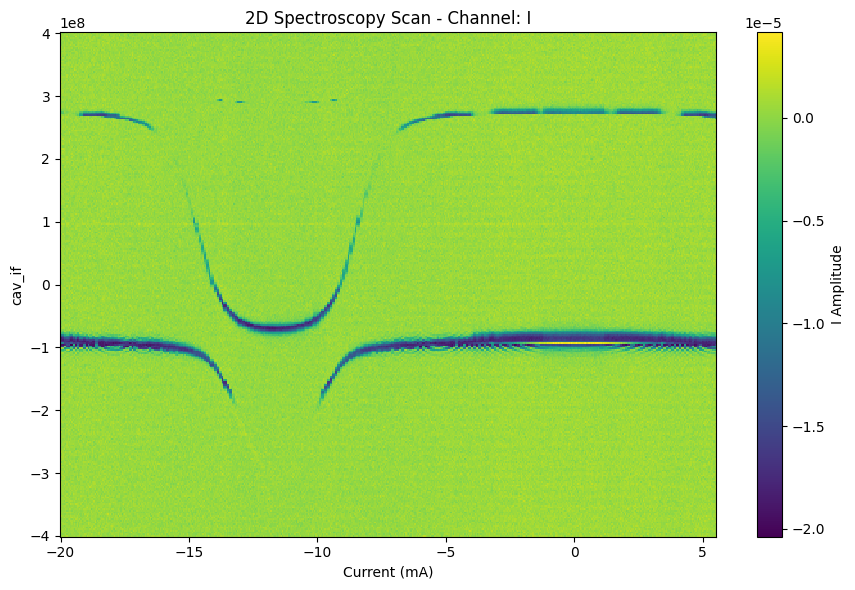

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# SELECTION CONFIGURATION
# ==========================================================
# Choose your channel here: "I", "Q", "MAG", or "PHASE"
CHOSEN_CHANNEL = "I"  

# Path to your master 2D dataset
file_path = r"C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data\SnailSpec_twotone_sideq_versus_flu_20260704_1906_to_20260705_0600_I.npz"

# ==========================================================
# LOAD AND COMPUTE
# ==========================================================
with np.load(file_path, allow_pickle=True) as data:
    current_mA = data["current_mA"]
    cav_if = data["cav_if"]
    
    I_matrix = data["I"]
    Q_matrix = data["Q"]

# Direct mapping dictionary using lazy computation
channel_map = {
    "I":     lambda: I_matrix,
    "Q":     lambda: Q_matrix,
    "MAG":   lambda: np.sqrt(I_matrix**2 + Q_matrix**2),
    "PHASE": lambda: np.arctan2(Q_matrix, I_matrix)  # Returns phase in radians (-π to π)
}

# Validate user choice safely
if CHOSEN_CHANNEL.upper() not in channel_map:
    raise ValueError(f"Invalid channel selection '{CHOSEN_CHANNEL}'. Choose from: {list(channel_map.keys())}")

# Extract selected matrix data
selected_matrix = channel_map[CHOSEN_CHANNEL.upper()]()

# Set up specific color map preferences (Phase looks much cleaner using a cyclic map like 'twilight')
cmap_choice = "twilight" if CHOSEN_CHANNEL.upper() == "PHASE" else "viridis"
cbar_label = "Phase (rad)" if CHOSEN_CHANNEL.upper() == "PHASE" else f"{CHOSEN_CHANNEL} Amplitude"

# ==========================================================
# GENERATE PLOT
# ==========================================================
plt.figure(figsize=(9, 6))

# .T transposes the data to align with current on X-axis and cav_if on Y-axis
plt.pcolormesh(current_mA, cav_if, selected_matrix.T, shading="auto", cmap=cmap_choice)

plt.xlabel("Current (mA)")
plt.ylabel("cav_if")
plt.title(f"2D Spectroscopy Scan - Channel: {CHOSEN_CHANNEL.upper()}")
plt.colorbar(label=cbar_label)

plt.tight_layout()
plt.show()